# MNIST


In [ ]:
from sklearn.datasets import fetch_openml

mnist = fetch_openml("mnist_784", version=1, as_frame=False)
mnist.keys()

dict_keys(['data', 'target', 'frame', 'categories', 'feature_names', 'target_names', 'DESCR', 'details', 'url'])

In [12]:
print(mnist.DESCR)

**Author**: Yann LeCun, Corinna Cortes, Christopher J.C. Burges  
**Source**: [MNIST Website](http://yann.lecun.com/exdb/mnist/) - Date unknown  
**Please cite**:  

The MNIST database of handwritten digits with 784 features, raw data available at: http://yann.lecun.com/exdb/mnist/. It can be split in a training set of the first 60,000 examples, and a test set of 10,000 examples  

It is a subset of a larger set available from NIST. The digits have been size-normalized and centered in a fixed-size image. It is a good database for people who want to try learning techniques and pattern recognition methods on real-world data while spending minimal efforts on preprocessing and formatting. The original black and white (bilevel) images from NIST were size normalized to fit in a 20x20 pixel box while preserving their aspect ratio. The resulting images contain grey levels as a result of the anti-aliasing technique used by the normalization algorithm. the images were centered in a 28x28 image b

In [13]:
X, y = mnist.data, mnist.target
print("X shape : ", X.shape)
print("y shape : ", y.shape)

X shape :  (70000, 784)
y shape :  (70000,)


There are 70,000 images, and each image has 784 features. This is because each image is 28×28 (28×28=784) pixels, and each feature simply represents one pixel’s intensity, from 0 (white) to 255 (black).


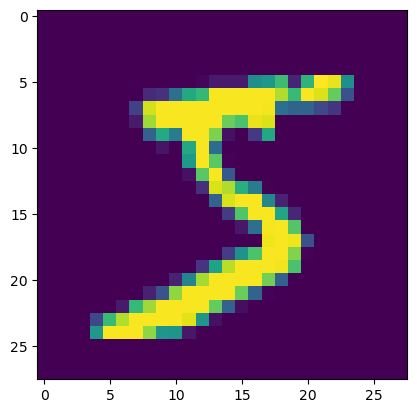

In [16]:
import matplotlib as mpl
import matplotlib.pyplot as plt

some_digit = X[0]
some_digit_img = some_digit.reshape(28, 28)

plt.imshow(some_digit_img)
plt.show()

In [17]:
y[0]

'5'

In [19]:
# The label is a string. So let’s cast y to integers
import numpy as np

y = y.astype(np.uint8)

In [22]:
# The MNIST dataset is actually already split into a
# training set (the first 60,000 images) and a test set (the last 10,000 images):

X_train, X_test, y_train, y_test = X[:60000], X[60000:], y[:60000], y[60000:]

### Training a Binary classifier

Let’s simplify the problem for now and only try to identify one digit—for example, the number 5. This “5-detector” will be an example of a binary classifier, capable of distinguishing between just two classes, 5 and not-5


In [ ]:
y_train_5 = y_train == 5
y_test_5 = y_test == 5

from sklearn.linear_model import SGDClassifier

sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(X_train, y_train_5)

,loss,'hinge'
,penalty,'l2'
,alpha,0.0001
,l1_ratio,0.15
,fit_intercept,True
,max_iter,1000
,tol,0.001
,shuffle,True
,verbose,0
,epsilon,0.1
,n_jobs,None


In [ ]:
sgd_clf.predict([some_digit])

array([ True])

### Measuring Accuracy Using Cross-Validation

In [25]:
from sklearn.model_selection import cross_val_score

cross_val_score(sgd_clf, X_train, y_train_5, cv=3, scoring='accuracy')

array([0.95035, 0.96035, 0.9604 ])

In [26]:
from sklearn.base import BaseEstimator


class Never5Classifier(BaseEstimator):
    def fit(self, X, y=None):
        pass

    def predict(self, X):
        return np.zeros((len(X), 1), dtype=bool)

never_5_clf = Never5Classifier()
cross_val_score(never_5_clf, X_train, y_train_5, cv=3, scoring="accuracy")

array([0.91125, 0.90855, 0.90915])

### Why Accuracy Can Be Misleading

Consider a very simple classifier that **always predicts "not 5"** for every image.

In the MNIST dataset, only about **10% of the images are actually the digit 5**, while the remaining **90% are not 5**.

If a model always predicts **"not 5"**, it will still be correct about **90% of the time**, even though it never correctly identifies a single digit 5.

This example shows that **accuracy alone can be misleading**, especially when the dataset is **imbalanced** (i.e., when one class appears much more frequently than the other).

Accuracy is not preferred for skewed datasets because a model can achieve high accuracy while completely failing to detect the minority class.

## Confusion Matrix

In [28]:
from sklearn.model_selection import cross_val_predict

y_train_pred = cross_val_predict(sgd_clf, X_train, y_train_5, cv = 3)
y_train_pred

array([ True, False, False, ...,  True, False, False], shape=(60000,))

In [29]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_train_5, y_train_pred)

array([[53892,   687],
       [ 1891,  3530]])

### Confusion Matrix

|                     | Predicted Negative  | Predicted Positive  |
| ------------------- | ------------------- | ------------------- |
| **Actual Negative** | True Negative (TN)  | False Positive (FP) |
| **Actual Positive** | False Negative (FN) | True Positive (TP)  |

**Interpretation:**

* **TN (True Negative):** Model correctly predicts the negative class.
* **TP (True Positive):** Model correctly predicts the positive class.
* **FN (False Negative):** Model incorrectly predicts negative when it is actually positive.
* **FP (False Positive):** Model incorrectly predicts positive when it is actually negative.


## Precision and Recall

### 1. What **Precision** Means

Precision answers the question:

> **When the model predicts positive, how often is it correct?**

Formula:

$$
\text{Precision} = \frac{TP}{TP + FP}
$$

Where:

* **TP (True Positive)** → correctly predicted positive
* **FP (False Positive)** → predicted positive but actually negative

---

### 2. Why Precision Alone Can Be Misleading

Imagine a dataset of **100 emails**.

| Type     | Count |
| -------- | ----- |
| Spam     | 20    |
| Not spam | 80    |

Now imagine a classifier that **labels only 1 email as spam**, and that email is actually spam.

Predictions:

| Prediction | Count |
| ---------- | ----- |
| Spam       | 1     |
| Not spam   | 99    |

Correct spam detection:

```
TP = 1
FP = 0
```

Precision:

$$
\frac{1}{1+0} = 1 = 100%
$$

So the model has **100% precision**.

But it detected only **1 out of 20 spam emails**, which is clearly bad.

This is why precision alone is not enough.

---

### 3. What **Recall** Measures

Recall answers a different question:

> **Out of all the actual positives, how many did the model detect?**

Formula:

$$
\text{Recall} = \frac{TP}{TP + FN}
$$

Where:

* **TP** → correctly predicted positives
* **FN (False Negative)** → missed positives

---

### 4. Example with Recall

Same spam example:

| Actual spam emails | 20 |
| ------------------ | -- |

The classifier detected only **1 spam email**.

So:

```
TP = 1
FN = 19
```

Recall:

$$
\frac{1}{1+19} = 0.05 = 5%
$$

So recall is **5%**, which is terrible.

---

### 5. Why We Need Both Precision and Recall

They measure **different things**:

| Metric    | Question it answers                                        |
| --------- | ---------------------------------------------------------- |
| Precision | When the model predicts positive, how often is it correct? |
| Recall    | How many actual positives did the model find?              |

---

### 6. Another Simple Example (Disease Detection)

Imagine **100 people**.

| Condition | Count |
| --------- | ----- |
| Sick      | 10    |
| Healthy   | 90    |

A test detects **3 sick people**, all correctly.

```
TP = 3
FP = 0
FN = 7
```

Precision:

$$
\frac{3}{3+0} = 100%
$$

Recall:

$$
\frac{3}{3+7} = 30%
$$

So the test is **very precise but misses many sick people**.

---

### 7. Key Idea

Precision alone can look **perfect** if the model predicts very few positives.

But recall shows **how many positives were actually detected**.

That’s why both metrics are used together.

---


In [32]:
from sklearn.metrics import precision_score, recall_score

print("Precision score : ", precision_score(y_train_5, y_train_pred))
print("Recall score : ", recall_score(y_train_5, y_train_pred))

Precision score :  0.8370879772350012
Recall score :  0.6511713705958311


# $F_1$ Score

The **F1 score** is the harmonic mean of **precision** and **recall**.

Unlike the regular (arithmetic) mean, the **harmonic mean gives more weight to smaller values**.
Because of this, a classifier will only achieve a **high $F_1$ score if both precision and recall are high**.

#### Formula

$$
F_1 = \frac{2}{\frac{1}{\text{precision}} + \frac{1}{\text{recall}}}
$$

This can also be written as:

$$
F_1 = 2 \times \frac{\text{precision} \times \text{recall}}{\text{precision} + \text{recall}}
$$

Using confusion matrix terms:

$$
F_1 = \frac{TP}{TP + \frac{FN + FP}{2}}
$$

Where:

* **TP** = True Positives
* **FP** = False Positives
* **FN** = False Negatives


In [34]:
from sklearn.metrics import f1_score

f1_score(y_train_5, y_train_pred)

0.7325171197343847

# Precision-Recall Tradeoff

In many classification problems, increasing **precision** usually decreases **recall**, and increasing **recall** usually decreases **precision**. This relationship is known as the **precision–recall tradeoff**.

Most classifiers compute a **score** for each instance and compare it with a **decision threshold**:

* If **score ≥ threshold → predict positive**
* If **score < threshold → predict negative**

Changing this threshold affects precision and recall.

---

### Increasing the Threshold

When the threshold is **increased**, the classifier becomes **more strict** about predicting the positive class.

* Fewer instances are predicted as positive.
* **False positives decrease** → precision increases.
* Some real positives are missed → recall decreases.

---

### Decreasing the Threshold

When the threshold is **decreased**, the classifier becomes **less strict**.

* More instances are predicted as positive.
* **More true positives are detected** → recall increases.
* But more false positives occur → precision decreases.

---

### Example

Suppose a classifier is detecting the digit **5**.

| Threshold      | Precision      | Recall      |
| -------------- | -------------- | ----------- |
| High threshold | High precision | Low recall  |
| Low threshold  | Low precision  | High recall |

---

### Key Idea

There is a **tradeoff between precision and recall**:

* Improving **precision** often reduces **recall**.
* Improving **recall** often reduces **precision**.

Choosing the right threshold depends on the **problem you are trying to solve**.


In [35]:

y_scores = sgd_clf.decision_function([some_digit])
y_scores

array([2164.22030239])

In [36]:
threshold = 0
y_some_digit_pred = y_scores > threshold
y_some_digit_pred

array([ True])

In [38]:
threshold = 8000
y_some_digit_pred = y_scores > threshold
y_some_digit_pred

array([False])

In [39]:
y_scores = cross_val_predict(
    sgd_clf, X_train, y_train_5, cv=3, method="decision_function"
)
y_scores

array([  1200.93051237, -26883.79202424, -33072.03475406, ...,
        13272.12718981,  -7258.47203373, -16877.50840447], shape=(60000,))

### Precision-Recall Curve

In [41]:
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(y_train_5, y_scores)

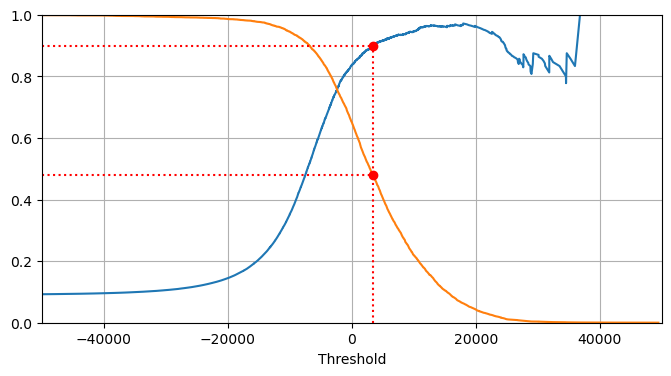

In [44]:
def plot_precision_recall_vs_threshold(precisions, recalls, thresholds):
    plt.plot(thresholds, precisions[:-1], label="Precisions")
    plt.plot(thresholds, recalls[:-1], label="Recalls")
    plt.xlabel("Threshold")
    plt.axis([-50000, 50000, 0, 1])
    plt.grid(True)

recall_90_precision = recalls[np.argmax(precisions >= 0.90)]
threshold_90_precision = thresholds[np.argmax(precisions >= 0.90)]


plt.figure(figsize=(8, 4))
plot_precision_recall_vs_threshold(precisions, recalls, thresholds)
plt.plot(
    [threshold_90_precision, threshold_90_precision], [0.0, 0.9], "r:"
)
plt.plot([-50000, threshold_90_precision], [0.9, 0.9], "r:")
plt.plot(
    [-50000, threshold_90_precision], [recall_90_precision, recall_90_precision], "r:"
)
plt.plot([threshold_90_precision], [0.9], "ro")
plt.plot([threshold_90_precision], [recall_90_precision], "ro")
plt.show()

In [ ]:
sgd_clf = SGDClassifier(random_state=42, n_jobs=-1)
sgd_clf.fit(X_train, y_train,)
sgd_clf.predict([some_digit])


array([3], dtype=uint8)

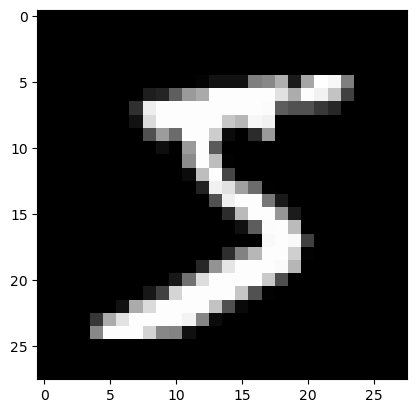

In [51]:
plt.imshow(some_digit.reshape(28, 28), cmap="gray")

In [58]:
decision_score = sgd_clf.decision_function([some_digit])
decision_score

array([[-31893.03095419, -34419.69069632,  -9530.63950739,
          1823.73154031, -22320.14822878,  -1385.80478895,
        -26188.91070951, -16147.51323997,  -4604.35491274,
        -12050.767298  ]])

In [57]:
np.argmax(decision_score)

np.int64(3)